# SCCA: Sparse Canonical Correlation Analysis

Sparse Canonical Correlation Analysis or SCCA relates two sets of variables which shares the same sample. It is similar to classical CCA except that it adds an $L_1$ penalty to both canonical vectors. Hence, each is defined only by a few variables. This technique makes SCCA usable on data or matrices which have more variables or columns than samples or rows. In this situation correlation of classical CCA will degrade but the sparsity penalty of SCCA will regularize the problem and at same time will select a small number of variables on each side that will drive the shared structure.



In this documentation, we will depomstrate implementation of SCCA using `BigRiverEssence.scca` on the `nutrimouse` dataset. 


## The method

Let us consider two data sets $X$ ($d_x$ variables) and $Y$ ($d_y$ variables). Both of them share the same $n$
samples. SCCA tries to canonical vectors $u$ and $v$ that maximize the covariance between
the projected variates $X^\top u$ and $Y^\top v$, using $L_1$ penalty on both. This makes the optimization problem as:
$$\max_{u,v} \; u^\top X Y^\top v \quad \text{subject to } \|u\|_2 \le 1,\ \|v\|_2 \le 1,\ \|u\|_1 \le c_1,\ \|v\|_1 \le c_2.$$
Here, the $L_1$ budgets are $c_1, c_2$ which force most entries of $u$ and $v$ to be $0$. This is what enables
canonical vector to selects only a few variables. The penalties `penaltyx` and `penaltyz` which belongs to $(0,1]$ are used for setting those budgets where a smaller values give sparser vectors.

In SCCA, each component is a ranked $1$ penalized approximation of the cross-product $XY^\top$. It is solved
by using analternating soft-thresholded power iteration. In this technique, we update $u$ from $XY^\top v$ and
soft-threshold it to its budget and update $v$ from $YX^\top u$ likewise, until they
converge. We obtain further components by deflating the data. This is the
penalized CCA method of Witten, Tibshirani & Hastie (2009). It is the same sparse-decomposition
framework underlying `pmd` and `spc` and applied here across two data sets.


## The data

We use the `nutrimouse` dataset from the `mixOmics` package. It records $120$ liver gene
expression and $21$ lipid concentrations on the same $40$ mice. Unlike what we did in the classical
CCA documentation, we keep all the variables in this setup.

In [ ]:
using BigRiverEssence, RCall, Plots, Statistics
const BRE = BigRiverEssence
gr()

R"""
suppressMessages(library(mixOmics))
data(nutrimouse)
genes  <- as.matrix(nutrimouse$gene)
lipids <- as.matrix(nutrimouse$lipid)
"""
gene_full   = rcopy(R"genes")            # 40 × 120
lipid_full  = rcopy(R"lipids")           # 40 × 21
gene_names  = rcopy(R"colnames(genes)")
lipid_names = rcopy(R"colnames(lipids)")
size(gene_full), size(lipid_full)

((40, 120), (40, 21))

## Preparing the blocks

`scca` regularizes with an $L_1$ penalty, hence it handles wide data directly. We use all the $120$
genes and $21$ lipids. Now, since `scca` expects the variables in the rows and observations
in the columns, so we transpose to form $X$ and $Y$.

In [8]:
X = Matrix{Float64}(transpose(gene_full))    # 120 × 40  (genes × mice)
Y = Matrix{Float64}(transpose(lipid_full))   # 21 × 40   (lipids × mice)
size(X), size(Y)

((120, 40), (21, 40))


## Fitting with model

Now we fit `scca` to $X$ and $Y$. The penalties control sparsity where smaller values select fewer variables. They are set using `penaltyx` and `penaltyz`. Here we set a penalty of $0.3$ on the
$120$ genes and $0.5$ on the $21$ lipids. We look at the sample correlation of the paired cannonical variates using `cors`.


In [ ]:
m = BRE.scca(X, Y; penaltyx = 0.3, penaltyz = 0.5, K = 1)
m.cors  

1-element Vector{Float64}:
 0.8869114536237

We see that the paired canonical variates correlate at 0.89 on the full wide data.

## Selected variables

We can get a peak of the nonzero entries of $u$ and $v$. These will give the selected genes and lipids.

In [13]:
gsel = findall(!iszero, m.u[:, 1])
lsel = findall(!iszero, m.v[:, 1])
@show length(gsel), length(lsel)
@show [gene_names[gsel]  m.u[gsel, 1]]      # selected genes and their weights
@show [lipid_names[lsel] m.v[lsel, 1]]      # selected lipids and their weights

(length(gsel), length(lsel)) = (18, 9)
[gene_names[gsel] m.u[gsel, 1]] = Any["ACOTH" -0.021396932337676103; "CAR1" -0.11602636228051999; "CYP3A11" 0.3644708872539295; "CYP4A10" 0.08538744437973658; "FAT" -0.30176128517019335; "GSTpi2" 0.34773840970296366; "Ntcp" -0.3348292225328909; "PDK4" -0.046925053115919706; "PMDCI" 0.32869830895556457; "RXRg1" -0.017429660958854946; "SIAT4c" -0.011601721250881608; "SPI1.1" 0.39691297187171165; "SR.BI" -0.42925048284901474; "UCP2" -0.17929938544788365; "VDR" -0.04381660056566555; "Waf1" -0.01688052649984104; "apoC3" -0.17333368274891406; "eif2g" -0.07057641317070149]
[lipid_names[lsel] m.v[lsel, 1]] = Any["C14.0" -0.0678322740802891; "C16.0" 0.0621288663984835; "C18.0" 0.6094584756207142; "C16.1n.9" -0.607325191819382; "C16.1n.7" -0.04256033900549788; "C18.1n.9" -0.34910774600559574; "C18.1n.7" -0.054401747236440985; "C20.3n.6" 0.2356288613991814; "C22.6n.3" 0.26284435170788656]


9×2 Matrix{Any}:
 "C14.0"     -0.0678323
 "C16.0"      0.0621289
 "C18.0"      0.609458
 "C16.1n.9"  -0.607325
 "C16.1n.7"  -0.0425603
 "C18.1n.9"  -0.349108
 "C18.1n.7"  -0.0544017
 "C20.3n.6"   0.235629
 "C22.6n.3"   0.262844

We not that, out of $120$ genes SCCA selected $18$ genes and out of $21$ lipids  it selected only $9$. The strongest gene weights fell on SR.BI, SPI1.1, CYP3A11, GSTpi2, Ntcp, PMDCI, and FAT. These are the genes involved in fatty-acid and
lipid transport and metabolism. Whereas the strongest lipid weighted on stearic acid (C18.0),
C16.1n.9, and oleic acid (C18.1n.9). Thus we can that the first sparse canonical pair therefore captured a metabolic link as a small set of lipid-handling genes co-varying with a small set of specific fatty acids across the mice.

## The canonical variate scatter

We can projecting the mice onto the sparse canonical vectors obtained by `scca` using the same standardization
`scca` applies internally. This will show us the paired variates.

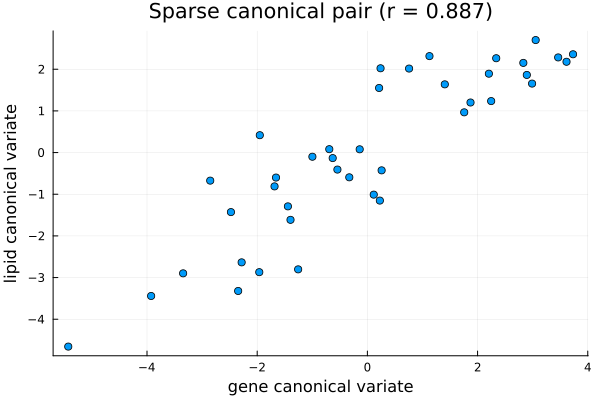

In [14]:
xs = (transpose(X) .- mean(transpose(X), dims = 1)) ./ std(transpose(X), dims = 1; corrected = true)
zs = (transpose(Y) .- mean(transpose(Y), dims = 1)) ./ std(transpose(Y), dims = 1; corrected = true)
xu = xs * m.u[:, 1]
zv = zs * m.v[:, 1]

scatter(xu, zv; legend = false,
    xlabel = "gene canonical variate", ylabel = "lipid canonical variate",
    title = "Sparse canonical pair (r = $(round(m.cors[1], digits = 3)))")

We see in the above plot where each point is a mouse placed by its gene-side and lipid-side canonical scores, the points
follow a clear line. Unlike in classical CCA, now the line is defined by only $18$ genes and
$9$ lipids rather than all $141$ variables. We obtained a correlation of $0.89$.

## Summary

We implemented SCCA on the full `nutrimouse` data considering all $120$ genes and $21$ lipids on $40$ mice. Using `scca` we found a sparse canonical pair correlating at $0.89$ and was able to select $18$ genes and $9$ lipids that together capture a
lipid-metabolism association. 